In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
TRAJECTORY_LEN = 1001
STATE_DIM = 29
# FEATURES_TO_CONSIDER = [0, 1, 15, 16]
FEATURES_TO_CONSIDER = torch.arange(29)

KEEP_ONLY_COORDS = True

In [3]:
def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('antmaze-large-diverse-v2')
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28
/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (32.560643788243, 25.145400704414648)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.21it/s]


In [5]:
dataset_trajectories = torch.tensor(dataset['observations'])
dataset_trajectories = dataset_trajectories[..., :STATE_DIM]
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions'])
dataset_terminals = torch.tensor(dataset['terminals'])
dataset_timeouts = torch.tensor(dataset['timeouts'])

dataset_goals = torch.tensor(dataset['infos/goal'])



# [:999*1001]

dataset_trajectories = dataset_trajectories[:999*1001].reshape(-1, 1001, STATE_DIM)
dataset_actions = dataset_actions[:999*1001].reshape(-1, 1001, 8)
dataset_terminals = dataset_terminals[:999*1001]
dataset_timeouts = dataset_timeouts[:999*1001]

num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [6]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])


def normalize_dataset_coords(dataset_, features_to_consider_only=False):
    is_numpy = isinstance(dataset_, np.ndarray)
    if is_numpy: dataset_ = torch.tensor(dataset_)
    dataset = dataset_.clone()
    if not features_to_consider_only:
        dataset = (dataset - dataset_mean) / dataset_std
    else:
        dataset = (dataset - dataset_mean[FEATURES_TO_CONSIDER]) / dataset_std[FEATURES_TO_CONSIDER]
    if is_numpy: dataset = np.array(dataset.cpu())
    return dataset

def denormalize_dataset_coords(dataset_, features_to_consider_only=False):
    is_numpy = isinstance(dataset_, np.ndarray)
    if is_numpy: dataset_ = torch.tensor(dataset_)
    dataset = dataset_.clone()
    if not features_to_consider_only:
        dataset = dataset * dataset_std + dataset_mean
    else:
        dataset = dataset * dataset_std[FEATURES_TO_CONSIDER] + dataset_mean[FEATURES_TO_CONSIDER]
    if is_numpy: dataset = np.array(dataset.cpu())
    return dataset

dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories_cuda = dataset_trajectories.to(device)


In [7]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a long enough PEs tensor
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # (1, max_len, d_model) so it can be broadcast over batch
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]  # match seq_len
        return self.dropout(x)


In [8]:
class FRENetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_heads=2, num_layers=2, d_model=128):
        super().__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.d_model = d_model
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.d_model, 
                num_heads, 
                dim_feedforward=4*self.d_model, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.d_model, self.d_model)
        self.encoder_log_std = nn.Linear(self.d_model, self.d_model)

        self.state_embed = nn.Linear(self.state_dim, self.d_model // 2)
        self.action_embed = nn.Linear(self.action_dim, self.d_model // 2)

        self.action_predict = nn.Sequential(
            nn.Linear(self.state_dim + self.d_model, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, action_dim),
            nn.Tanh()
        )
        
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=0.1, max_len=200)



    def get_transformer_encoding(self, states, actions, pad_mask):  
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=states.device)
        # pad_mask.shape = [batch, anchors]
                
        state_emb = self.state_embed(states)
        action_emb = self.action_embed(actions)
        
        state_action_emb = torch.concat([state_emb, action_emb], dim=-1)
        
        x = self.positional_encoding(state_action_emb)
        w_pre = self.encoder_transformer(x, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_action_pred(self, w, states): # Reward Pairs: [batch, seq, obs_dim]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, states], axis=-1)
        
        reward_pred = self.action_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

# Reward Generator:

In [9]:
EPISODE_LENGTH = TRAJECTORY_LEN
Z_DIM = 128
MIN_NUM_ANCHORS = 16
MAX_NUM_ANCHORS = 16

In [10]:
from utils.reward_alignement import RNDModule, RNDResampling, RewardGeneratorTransformer

In [11]:
class RewardGenerator:
    def __init__(self, fre_network: RewardGeneratorTransformer):
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)
        
        self.len_params = Z_DIM
        self.resampling_weights = None
        
    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    
    
    def get_training_data(self, batch_size, min_num_anchors, max_num_anchors):
        assert min_num_anchors <= max_num_anchors

        obs_dim = dataset_trajectories.shape[-1]
        

        # buffer = dataset_trajectories[..., :2].reshape(-1, 2)
        buffer = dataset_trajectories[..., :].reshape(-1, obs_dim)
        
        anchors = torch.zeros((batch_size, max_num_anchors, obs_dim), dtype=torch.float32)

        idx = self.get_importance_sampling_indices(batch_size*max_num_anchors,)
        # anchors = buffer[idx, :2]
        anchors = buffer[idx, :]
        anchors = anchors.reshape(batch_size, max_num_anchors, obs_dim)

            
        anchors_rewards = torch.zeros((batch_size, max_num_anchors), dtype=torch.float32)
        pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)

        # Generate random number of anchors for each batch element
        num_anchors = torch.randint(min_num_anchors, max_num_anchors + 1, (batch_size,))

        reward_indices = torch.arange(max_num_anchors).unsqueeze(0)
        reward_mask = reward_indices < num_anchors.unsqueeze(1)

        
        candidates = torch.tensor([-1, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.])
        
        anchors_rewards[reward_mask] = candidates[torch.randint(0, candidates.shape[0], (reward_mask.sum(),))]
        
        # Goal reaching reward functions:
        # random_rows = torch.tensor([n for n in range(batch_size) if random.random() < 0.3], dtype=torch.long)
        # anchors_rewards[random_rows] = 0.
        # anchors_rewards[random_rows, 0] = 1.
            
        # rewards[reward_mask] = torch.exp(2*(rewards[reward_mask] - 1))
        anchors_rewards = anchors_rewards.unsqueeze(-1)

        pad_mask_indices = torch.arange(max_num_anchors).unsqueeze(0)
        pad_mask = pad_mask_indices < num_anchors.unsqueeze(1)
        pad_mask = ~pad_mask
                
        
        anchors = anchors[..., FEATURES_TO_CONSIDER].float()
        anchors_rewards = anchors_rewards.float()
        pad_mask = pad_mask
        
        return (anchors, anchors_rewards, pad_mask), {}
    

    def generate_boolean_mask(self, batch_size, length, p=0.9):
        vecs = (torch.rand(batch_size, length) > p).bool()
        mask = ~vecs.any(dim=1)
        if mask.any():
            rows = mask.nonzero(as_tuple=False).squeeze(1)
            cols = torch.randint(0, length, (rows.size(0),))
            vecs[rows, cols] = True
        
        
        if KEEP_ONLY_COORDS:
            vecs = torch.zeros_like(vecs)
            vecs[:, :2] = True
        return vecs * 1.
    
        
    def train_step_VAE(self, batch_size, min_num_anchors, max_num_anchors):
        self.fre_network.train()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        mask = self.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.5)
        if KEEP_ONLY_COORDS:
            mask = torch.zeros_like(mask)
            mask[..., :2] = 1.
        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
        

        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)
        
        
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = w_mean
        rewards_pred = self.fre_network.get_reward_pred(w, anchors)
        
        
        reward_pred_loss = ((rewards_pred[~pad_mask] - anchors_rewards[~pad_mask])**2).mean()
                        
        
        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = reward_pred_loss + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'reward_pred_loss': reward_pred_loss.item(),
            'kl_loss': kl_loss.item(),
            'get_training_data:info': info,
            'anchors': anchors.cpu(),
            'anchors_rewards': anchors_rewards.cpu(),
            'pad_mask': pad_mask.cpu(),
        }
        
    
    def get_z_from_random_anchors(self, batch_size: int, min_num_anchors:int, max_num_anchors:int, mask=None):
        self.fre_network.eval()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        if mask is None:
            mask = self.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.0)
        
        assert mask.shape == (batch_size, len(FEATURES_TO_CONSIDER))
        
        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
        
        eval_z, _ = self.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
        
        return eval_z, {
            'anchors': anchors.cpu(), 
            'anchors_rewards': anchors_rewards.cpu(), 
            'pad_mask': pad_mask.cpu(), 
            'get_training_data:info': info
        }
    

    def get_z_from_anchors(self, anchors: torch.Tensor, anchors_rewards: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.eval()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask) 
        
        # eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        # z = w_mean + eps * torch.exp(w_log_std)
        z = w_mean
        
        return z, {'anchors': anchors.cpu()}
            
    
    def get_importance_sampling_indices(self, N):
        indices = torch.multinomial(self.resampling_weights, N, replacement=True)
        return indices

In [12]:
num_anchors = 16

rg_model = RewardGeneratorTransformer(obs_len=len(FEATURES_TO_CONSIDER))
rg_model.load_state_dict(torch.load('models/all_in_one-coords-rg_model.pth'))

reward_generator = RewardGenerator(
    fre_network=rg_model,
)

resampler = RNDResampling(state_dim=2)
rnd_dataset = dataset_trajectories[..., :2].reshape(-1, 2)
resampler_losses = resampler.fit(rnd_dataset, epochs=1000)
resampling_weights = resampler.get_resampling_weights(rnd_dataset, alpha=1.2)
reward_generator.resampling_weights = resampling_weights


vae_loss, vae_kl_loss = [], []

/tmp/ipykernel_6393/1664445458.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rg_model.load_state_dict(torch.load('models/all_in_one-coords-rg_model.pth'))
100%|███████

In [13]:
# print('VAE training...')
# for step in tqdm(range(100_000), desc='VAE training', leave=False):
    
#     vae_loss_dict = reward_generator.train_step_VAE(
#         batch_size=256,
#         min_num_anchors=MIN_NUM_ANCHORS,
#         max_num_anchors=MAX_NUM_ANCHORS,
#     )
#     vae_loss.append(vae_loss_dict['loss'])
#     vae_kl_loss.append(vae_loss_dict['kl_loss'])   
    
#     if step % 100 == 0:
#         clear_output(True)
#         fig, axs = plt.subplots(1, 2, figsize=(10, 4))
#         axs[0].plot(vae_loss)
#         axs[0].set_ylim([0, 0.5])
#         axs[0].set_xscale('log')
#         axs[1].plot(vae_kl_loss)
#         axs[1].set_ylim([0, 1])
#         plt.show()
        
#     # break


In [14]:
# torch.save(rg_model.state_dict(), 'models/all_in_one-coords-rg_model.pth')

In [15]:

def visualize_rewards_and_trajectories(eval_z, reward_generator, anchors=None, anchors_rewards=None, pad_mask=None, mask=None):

    state = dataset_trajectories[0:300, :1000:10].reshape(-1, obs_dim)
    state = state.to(device)


    num_evals = eval_z.shape[0]
    num_rows = int(np.floor(num_evals/4))
    num_rows += 1 if (num_rows == 0) or num_evals % (num_rows*4) != 0 else 0
    fig, axs = plt.subplots(num_rows, 4, figsize=(20, num_rows*4))
    axs = axs.flatten()
    
    
    if (anchors is not None) and (anchors_rewards is not None) and (pad_mask is not None):
        anchors_rewards = anchors_rewards * 0.5 + 0.5
        anchors_rewards = anchors_rewards.clip(0, 1)
        anchors_rewards = anchors_rewards * 20
        anchors_rewards = anchors_rewards + 0.1
                
        anchors = np.where(~pad_mask[..., None], anchors, None)
        anchors_rewards = np.where(~pad_mask[..., None], anchors_rewards, 0)
        
        

    for i in range(len(eval_z)):
        
        zi = eval_z[i].unsqueeze(0).repeat(state.shape[0], 1)
        with torch.no_grad():
            x = state[..., FEATURES_TO_CONSIDER]
            if mask is not None:
                x = x * mask[i].unsqueeze(0).repeat(state.shape[0], 1).to(device)
            # x = torch.zeros_like(x)
            r = reward_generator.get_reward(x, zi).cpu()

        
        axs[i].scatter(state[:, 0].cpu(), state[:, 1].cpu(), c=r, alpha=0.7, s=20, vmin=-1, vmax=1)
        
        if (anchors is not None) and (anchors_rewards is not None) and (pad_mask is not None):
            axs[i].scatter(anchors[i, :, 0], anchors[i, :, 1], c='red', s=anchors_rewards[i, :, 0].reshape(-1))
    

    return fig, axs, {'state':state.cpu(), 'r':r.cpu()} 

In [16]:
# eval_num_envs = 4
# num_anchors = 16

# mask = reward_generator.generate_boolean_mask(eval_num_envs, len(FEATURES_TO_CONSIDER), p=0.0)
# # mask = torch.zeros_like(mask)
# # mask[..., [0, 1]] = 1.
# with torch.no_grad():
#     w, info = reward_generator.get_z_from_random_anchors(eval_num_envs, min_num_anchors=num_anchors, max_num_anchors=num_anchors, mask=mask)
    
# fig, axs, visualize_info = visualize_rewards_and_trajectories(w, reward_generator, mask=mask)

# # info['anchors_rewards'].flatten()

In [17]:
# plt.scatter(visualize_info['state'][:, 15], visualize_info['state'][:, 16], c=visualize_info['r'])

# All in one:

In [18]:
def get_training_data_agent(batch_size, num_anchors, num_states, trajectories_idx_=None):
    
    num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape
    
    if trajectories_idx_ is not None:
        batch_size = len(trajectories_idx_)
        
    if trajectories_idx_ is None: 
        trajectories_idx_ = torch.randint(0, num_trajectories, (batch_size,))      
        
    trajectories_idx_ = trajectories_idx_.unsqueeze(-1).long()    
    
    
    trajectories_idx = trajectories_idx_.repeat(1, num_anchors).reshape(-1)
    states_idx = torch.linspace(0, len_trajectory-1, num_anchors).long().repeat(batch_size)
    anchors = dataset_trajectories[trajectories_idx, states_idx].reshape(batch_size, num_anchors, -1)
    anchors_actions = dataset_actions[trajectories_idx, states_idx].reshape(batch_size, num_anchors, -1)
    
    
    trajectories_idx = trajectories_idx_.repeat(1, num_states).reshape(-1)
    states_idx = torch.linspace(0, len_trajectory-1, num_states).long().repeat(batch_size)
    states = dataset_trajectories[trajectories_idx, states_idx].reshape(batch_size, num_states, -1)
    actions = dataset_actions[trajectories_idx, states_idx].reshape(batch_size, num_states, -1)
    
    
    return (anchors.to(device), anchors_actions.to(device)), (states.to(device), actions.to(device)), {'trajectories_idx': trajectories_idx_}

In [19]:
class RewardFunctionEncoder(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.init_state_embed = nn.Linear(2, self.reward_pairs_emb_dim)
        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
        )



    def get_transformer_encoding(self, init_state, states, rewards, pad_mask):  
        
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        # reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.floor((rewards*0.5+0.5) * self.num_discrete_embeddings).int() # dont forget that rewards are in [-1, 1]
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)
        
        init_state_emd = self.init_state_embed(init_state).unsqueeze(1)
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)      
        # x = torch.concat((init_state_emd, state_reward_emd), dim=1)
        # pad_mask = torch.concat((pad_mask, pad_mask[:, [0]]), dim=1)
        
        w_pre = self.encoder_transformer(state_reward_emd, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [20]:
def get_best_trajectory(start_states, reward_w, num_considered_steps=100):
    
    best_traj_w = []
    best_traj_idx = []
    cumm_r_list = []

    for i in range(reward_w.shape[0]):
        
        start_states = start_states.to(device)
        
        cond = (torch.norm(dataset_trajectories_cuda[:, ::, :2] - start_states[i, :2].unsqueeze(0), p=2, dim=2) < 0.1)

        valid_trajectories_bool = cond.any(dim=1) # True if the trajectory contains the start_state, otherwise False
        valid_trajectories_idx = torch.nonzero(valid_trajectories_bool).flatten() # The indicies of the trajectories containing the start_state
        valid_start_states_idx = cond[valid_trajectories_bool].long().argmax(dim=1) # The index of the start_state in each trajectory (the start of the sub-trajectory)
        # print(valid_trajectories_idx)
        # print(valid_start_states_idx)
        # break

        # The index of the states from each sub-trajectory        
        valid_start_states_idx = valid_start_states_idx.unsqueeze(1)  # (N, 1)
        step_fractions = torch.linspace(0, 1, num_considered_steps, device=valid_start_states_idx.device)  # (S,)
        state_idx = valid_start_states_idx + (TRAJECTORY_LEN - 1 - valid_start_states_idx) * step_fractions  # (N, S)
        state_idx = state_idx.long()  # Optional: use .floor() or .ceil() depending on behavior

        
        # x = torch.stack([dataset_trajectories_cuda[valid_trajectories_idx[i], state_idx[i], :2] for i in range(len(valid_trajectories_idx))])
        # x = dataset_trajectories_cuda[valid_trajectories_idx[:, None], state_idx, :2]
        x = dataset_trajectories_cuda[valid_trajectories_idx[:, None], state_idx][..., FEATURES_TO_CONSIDER]
        
        num_filtered_trajectories, _, obs_dim = x.shape
        
        x = x.reshape(-1, obs_dim).to(device)
        w = reward_w[[i]].repeat(x.shape[0], 1)

        with torch.no_grad():
            r = reward_generator.get_reward(x, w).reshape(num_filtered_trajectories, num_considered_steps)
            
            # Calculate the sum of all reward over the trajectories
            cumm_r = r.sum(-1)

        # Find the index of the best trajectory in the set of valid trajectories
        relative_traj_max_idx = cumm_r.argmax().item()
        
        # Find the index of the best trajectory in the of all trajectories
        traj_max_idx = torch.arange(0, num_trajectories)[valid_trajectories_bool.cpu()][relative_traj_max_idx]
        
        best_traj_idx.append(torch.arange(0, num_trajectories)[valid_trajectories_bool.cpu()][cumm_r.argsort(descending=True).cpu()])
        # best_traj_w.append(pre_computed_zs[traj_max_idx])
        cumm_r_list.append(cumm_r.sort(descending=True).values.cpu())
    
    # The representations of the best trajectories:
    best_traj_w = torch.stack(best_traj_w).to(device) if best_traj_w else best_traj_w
    # best_traj_idx = torch.stack(best_traj_idx)
    
    return best_traj_w, {'best_traj_idx': best_traj_idx, 'cumm_r': cumm_r_list}

In [21]:
def sample_reward_function(reward_generator, batch_size, num_random_samples, min_num_anchors, max_num_anchors):

    start_states = torch.tensor([[0.01172762, 0.14960599]]).repeat(batch_size, 1)

    # get a random reward function from the reward generator:
    with torch.no_grad():
        mask = reward_generator.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.5)
        if KEEP_ONLY_COORDS:
            mask = torch.zeros_like(mask)
            mask[..., [0, 1]] = 1.
        reward_latent, info = reward_generator.get_z_from_random_anchors(
            batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors, 
            mask=mask
        )


    # Get the representation of the reward function based on random states:
    abs_states_idx = reward_generator.get_importance_sampling_indices(batch_size*num_random_samples)
    trajectories_idx, states_idx = abs_states_idx // len_trajectory, abs_states_idx % len_trajectory
    random_states = dataset_trajectories[trajectories_idx, states_idx] # get the random states
    random_states = random_states.reshape(batch_size, num_random_samples, len(FEATURES_TO_CONSIDER)).to(device)


    # Calculate the rewards of the selected random states using the trained Reward Function Generator:
    with torch.no_grad():
        random_states_rewards = reward_generator.get_reward(
            random_states.reshape(-1, len(FEATURES_TO_CONSIDER)) * mask.repeat(num_random_samples, 1).to(device),
            reward_latent.unsqueeze(1).repeat(1, num_random_samples, 1).reshape(-1, Z_DIM)
        )
    random_states_rewards = random_states_rewards.reshape(batch_size, num_random_samples)
    
    return start_states, reward_latent, random_states, random_states_rewards, {**info} 

In [22]:
batch_size = 32
num_considered_steps = 100
num_random_samples = 200
num_trajectories, len_trajectory, obs_len = dataset_trajectories.shape

In [23]:
trajectory_vae = FRENetwork(state_dim=obs_dim, action_dim=8, num_layers=2, num_heads=2).to(device)
trajectory_vae_optimimizer = torch.optim.Adam(trajectory_vae.parameters(), lr=0.001)
kl_losses = []
bc_losses = []

reward_encoder = RewardFunctionEncoder(obs_len=len(FEATURES_TO_CONSIDER), num_heads=2, num_layers=2).to(device)
reward_encoder_optimizer = torch.optim.Adam(reward_encoder.parameters(), lr=0.001)
representation_alignement_losses = []

losses = []

/tmp/ipykernel_6393/1067900953.py:72: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[0].set_xscale('log')


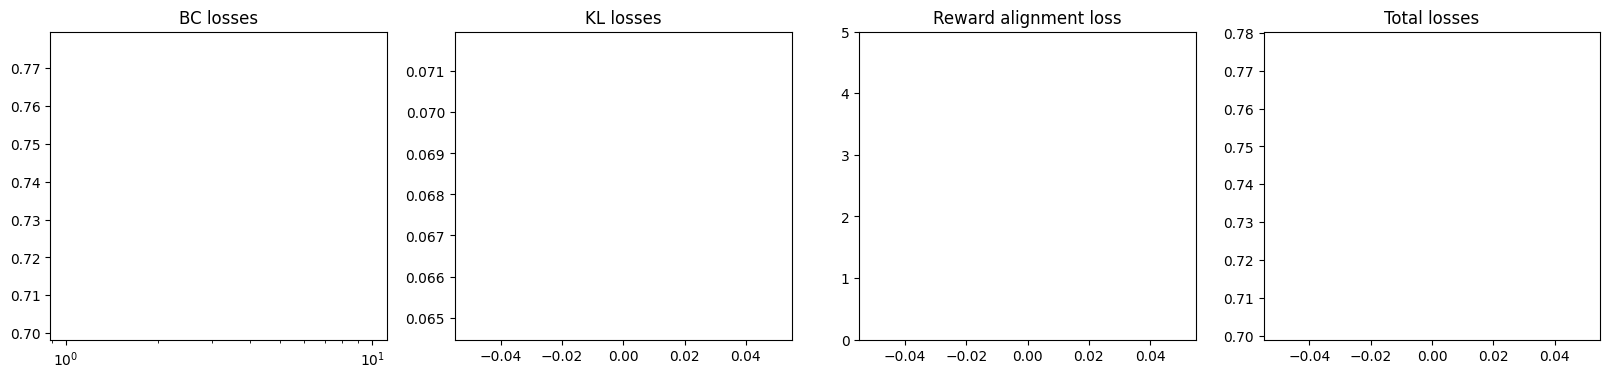

  0%|          | 0/10000 [00:01<?, ?it/s]


In [24]:
for step in tqdm(range(10_000)):
    # 1) Sample a reward function from the reward generator
    start_states, reward_latent, random_states, random_states_rewards, sample_reward_function_info = sample_reward_function(
        reward_generator=reward_generator,
        batch_size=batch_size,
        num_random_samples=200,
        min_num_anchors=8,
        max_num_anchors=8,
    )

    # 2) get the representation `Z_r` of the sampled reward function:
    random_states_pad_mask = torch.full((batch_size, num_random_samples), fill_value=False, device=device)
    Z_r_mean, Z_r_log_std = reward_encoder.get_transformer_encoding(
        start_states.to(device),
        random_states, 
        random_states_rewards, 
        pad_mask=random_states_pad_mask
    )
    eps = torch.normal(0, 1, Z_r_mean.shape, device=device)
    Z_r = Z_r_mean + eps * torch.exp(Z_r_log_std)

    # 3) Get the best trajectory for the sampled reward function:
    _, get_best_trajectory_info = get_best_trajectory(
        start_states=start_states,
        reward_w=reward_latent,
        num_considered_steps=num_considered_steps
    )
    best_traj_idx = torch.stack([x[0] for x in get_best_trajectory_info['best_traj_idx']])
    
    # 4) Get the representation `r` rf the best trajectory:
    (trajectory_anchors_states, trajectory_anchor_actions), (trajectory_states, trajectory_actions), get_training_data_agent_info = get_training_data_agent(
        batch_size=batch_size,
        num_anchors=200,
        num_states=1000,
        trajectories_idx_=best_traj_idx
    )
    Z_t_mean, Z_t_log_std = trajectory_vae.get_transformer_encoding(trajectory_anchors_states, trajectory_anchor_actions, pad_mask=None)
    eps = torch.normal(0, 1, Z_t_mean.shape, device=device)
    Z_t = Z_t_mean + eps * torch.exp(Z_t_log_std)

    # 5) Predict the actions for the trajectory states:
    # pred_trajectory_actions = trajectory_vae.get_action_pred(Z_t, trajectory_states)
    pred_trajectory_actions = trajectory_vae.get_action_pred(Z_r, trajectory_states)

    # 6) Calculate the losses:
    BC_loss = (pred_trajectory_actions - trajectory_actions).pow(2).mean() # Agent BC loss 

    representation_alignement_loss = (Z_t_mean - Z_r_mean).pow(2).sum(-1).mean() # difference between the reward and the trajectory representation

    # kl_loss = -0.5 * (1 + 2*Z_t_log_std - Z_t_mean**2 - torch.exp(Z_t_log_std)**2).mean() # KL term
    kl_loss = -0.5 * (1 + 2*Z_r_log_std - Z_r_mean**2 - torch.exp(Z_r_log_std)**2).mean() # KL term


    loss = BC_loss + 0.0*representation_alignement_loss + 0.01*kl_loss

    trajectory_vae_optimimizer.zero_grad()
    reward_encoder.zero_grad()
    loss.backward()
    trajectory_vae_optimimizer.step()
    reward_encoder_optimizer.step()
    
    bc_losses.append(BC_loss.item())
    kl_losses.append(kl_loss.item())
    representation_alignement_losses.append(representation_alignement_loss.item())
    losses.append(loss.item())
    

    if step % 10 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 4, figsize=(20, 4))
        axs[0].plot(bc_losses)
        axs[0].set_xscale('log')
        axs[0].set_title('BC losses')
        axs[1].plot(kl_losses)
        axs[1].set_title('KL losses')
        axs[2].plot(representation_alignement_losses)
        axs[2].set_ylim([0, 5])
        axs[2].set_title('Reward alignment loss')
        axs[3].plot(losses)
        axs[3].set_title('Total losses')
        plt.show()
        
    break

In [30]:
get_best_trajectory_info['best_traj_idx'][0]

tensor([199, 172, 210, 339, 688, 433,  12,  60, 240, 194, 516, 898, 452, 614,
        380, 437, 340,  54, 277, 611,  93, 263, 652, 817, 829,  32, 848, 845,
        872, 257, 979, 939, 267, 427, 347, 714, 677, 786, 830, 583, 963, 838,
        358, 251, 296, 425, 914, 559, 228, 936, 443, 904, 644, 822, 599, 140,
        193, 961, 744, 796, 127, 935, 916, 208, 379, 909, 557, 258, 697, 103,
        503, 344, 447, 181, 531, 268, 225, 235, 976, 741,  46, 931, 396, 932,
        859, 198, 252, 234, 816, 533, 456,  66, 399, 465,   5,  28, 880,  49,
        573, 550, 706, 264, 631,  82, 442, 791, 110, 176, 681, 271, 971, 642,
        862,  94, 528,   3, 792, 755, 313, 211, 546, 895, 836, 876, 824, 438,
        200, 130, 708, 113, 837,  52, 316, 866, 878,  85, 831, 499, 785,  92,
        672, 350, 867, 361, 724, 779, 484, 423, 402, 900, 371, 801, 173, 994,
        535, 574, 509, 153,  71, 736, 687, 332, 852, 523,  10, 746, 784, 982,
        375, 703, 698, 189, 451, 944, 238, 343, 804, 171, 809, 5

In [216]:
# fig, axs, visualize_info = visualize_rewards_and_trajectories(reward_latent, reward_generator, mask=None)

# for b in range(batch_size):
#     axs[b].scatter(random_states[b, :, 0].cpu(), random_states[b, :, 1].cpu(), c=random_states_rewards[b].cpu(), edgecolor='red')
#     axs[b].scatter(dataset_trajectories[best_traj_idx[b], :, 0], dataset_trajectories[best_traj_idx[b], :, 1], c='red')

In [475]:
num_trajectories = dataset_trajectories.shape[0]
indicies = torch.arange(0, num_trajectories, dtype=torch.long)

z_list = []

for i in tqdm(range(0, num_trajectories, 512)):
    traj_idx = indicies[i:i+512]
    
    (anchors, anchor_actions), _, info = get_training_data_agent(
        batch_size=-1,
        num_anchors=200,
        num_states=1,
        trajectories_idx_=traj_idx
    )
    

    anchors, anchor_actions = anchors.to(device), anchor_actions.to(device)
    with torch.no_grad():
        trajectory_vae.eval()
        z, _ = trajectory_vae.get_transformer_encoding(anchors, anchor_actions, pad_mask=None)
    
    
    z_list.append(z)
    
zs = torch.concat(z_list).cpu()

pre_computed_zs = zs

100%|██████████| 2/2 [00:00<00:00, 15.07it/s]


In [33]:
import matplotlib.patches as patches


def add_largest_maze_walls(ax):    

    maze_optim = [
        (1, 1, 1, 2),    
        (0, 4, 2, 1),
        (3, 1, 1, 4),
        (5, 0, 1, 1),
        (4, 2, 3, 1),
        (1, 6, 3, 1),
        (4, 4, 2, 1),
        (5, 6, 2, 1),
        (1, 8, 1, 1),
        (3, 7, 1, 2),
        (5, 8, 1, 2)
    ]

    block_size = 0.2

    height, width = 10, 10
    torso_x, torso_y = (width - 1)*block_size, (height - 1)*block_size

    rects = []
    for i in range(len(maze_optim)):
        (y, x, w, h) = maze_optim[i]
            
        x = x * block_size * 2 - torso_x + (h - 1) * block_size - h * block_size
        y = y * block_size * 2 - torso_y + (w - 1) * block_size - w * block_size
        h, w = h * block_size * 2, w * block_size * 2
        w = w * 1.2
        y = y * 1.2
        rect = patches.Rectangle((x-0.17, y+0.5), h, w, linewidth=2, edgecolor='gray', facecolor='gray')

        ax.add_patch(rect)
        
        

def get_eval_rewards(eval_z, to_keep:list=None): 
    states = dataset_trajectories[0:300, :1000:10].reshape(-1, obs_dim)
    states = states.to(device)

    res = []
    for i in range(len(eval_z)):
        
        zi = eval_z[i].unsqueeze(0).repeat(states.shape[0], 1)
        with torch.no_grad():
            x = states
            if to_keep is not None:
                x = torch.zeros_like(x)
                x[..., to_keep] = states[..., to_keep]
            r = reward_generator.get_reward(x, zi).cpu()
            res.append(r)
    
    res = torch.stack(res).squeeze(-1)
    
    return x.cpu(), res.cpu()

In [34]:
# b = 17
# tmp_t = (Z_t_mean[[b]].cpu() - pre_computed_zs).pow(2).sum(-1).argsort()
# tmp_r = (Z_r[[b]].cpu() - pre_computed_zs).pow(2).sum(-1).argsort()


# fig, ax = plt.subplots(1, 1)

# states, rewards = get_eval_rewards(reward_latent[[b]], to_keep=[0, 1])
# states.shape, rewards.shape
# ax.scatter(states[..., 0], states[..., 1], c=rewards)

# ax.plot(dataset_trajectories[best_traj_idx[b], :, 0], dataset_trajectories[best_traj_idx[b], :, 1], c='blue', linewidth=7)
# for i in range(1):
#     ax.plot(dataset_trajectories[tmp_t[i], :, 0], dataset_trajectories[tmp_t[i], :, 1], c='red', linewidth=4)
# for i in range(1):
#     ax.plot(dataset_trajectories[tmp_r[i], :, 0], dataset_trajectories[tmp_r[i], :, 1], c='green', linewidth=2)
    
    
# add_largest_maze_walls(ax)

In [96]:
start_states, reward_latent, random_states, random_states_rewards, sample_reward_function_info = sample_reward_function(
    reward_generator=reward_generator,
    batch_size=1,
    num_random_samples=200,
    min_num_anchors=8,
    max_num_anchors=8,
)


env.reset()
# location = np.array(env.unwrapped._wrapped_env._get_reset_location())
location = (20, 15)
start_state = reset_to_location(env, location)
start_state = normalize_dataset_coords(start_state)[..., :]
state = start_state

tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()

random_states_pad_mask = torch.full((1, num_random_samples), fill_value=False, device=device)
trajectory_z, _ = reward_encoder.get_transformer_encoding(
    start_states.to(device),
    random_states, 
    random_states_rewards, 
    pad_mask=random_states_pad_mask
)


_, get_best_trajectory_info = get_best_trajectory(
    start_states=start_states,
    reward_w=reward_latent,
    num_considered_steps=num_considered_steps
)
best_traj_idx = torch.stack([x[0] for x in get_best_trajectory_info['best_traj_idx']])


# Get the best trajectory from the dataset:
# predcited_best_w, get_best_trajectory_info = get_best_trajectory_for_benchmark(tensor_state[:, :2].cpu(), benchmark_reward_function, benchmark_param)


# Run the agent conditioned on the predicted trajectory representation:

produced_trajectory = []

for step in tqdm(range(10)):
    
    produced_trajectory.append(state)
    
    if step % 10 == 0:
        tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()
    
    with torch.no_grad():
        tensor_state = torch.tensor(state).reshape(1, 1, -1).to(device).float()
        # action = trajectory_vae.get_action_pred(predcited_best_w, tensor_state).cpu()
        action = trajectory_vae.get_action_pred(trajectory_z, tensor_state).cpu()
        action = np.array(action[0, 0])
        
    new_state, _, _, _ = env.step(action)
    
    state = normalize_dataset_coords(new_state)[..., :]
    
    
    
produced_trajectory = np.stack(produced_trajectory)

Target Goal:  (32.80267302484067, 24.64673922253787)


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 661.25it/s]


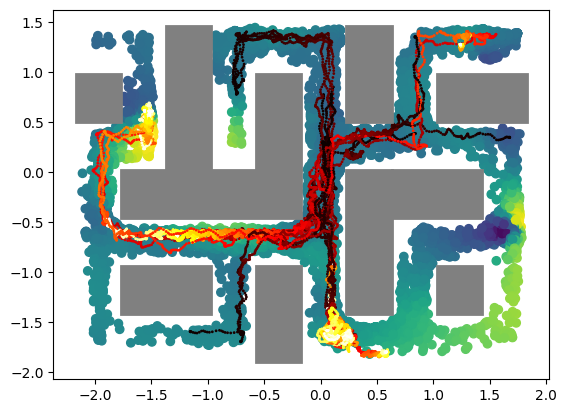

In [98]:
fig, ax = plt.subplots(1, 1)

states, rewards = get_eval_rewards(reward_latent, to_keep=[0, 1])
states.shape, rewards.shape
ax.scatter(states[..., 0], states[..., 1], c=rewards)
# ax.scatter(random_states[..., 0].cpu(), random_states[..., 1].cpu(), c=random_states_rewards.cpu(), edgecolors='red')

# ax.plot(produced_trajectory[..., 0], produced_trajectory[..., 1], c='blue', linewidth=7)
# ax.plot(dataset_trajectories[best_traj_idx[0], :, 0], dataset_trajectories[best_traj_idx[0], :, 1], c='red', linewidth=7)

for i in get_best_trajectory_info['best_traj_idx'][0][:20]:
    # ax.plot(dataset_trajectories[i, :, 0], dataset_trajectories[i, :, 1], c='red', linewidth=1)
    ax.scatter(dataset_trajectories[i, :, 0], dataset_trajectories[i, :, 1], c=torch.linspace(0, 1, 1001), s=1, cmap='hot')

add_largest_maze_walls(ax)

# Benchmark:

In [478]:
from utils.antmaze_benchmark import VelocityRewardFunction, SimplexRewardFunction, TestRewPath, TestRewLoop, TestRewMatrixEdges, goal_reaching_reward

velocity_reward_function = VelocityRewardFunction()
simplex_reward_function = SimplexRewardFunction(num_simplex=10)

benchmarks = [
    (goal_reaching_reward, 'goal_bottom', np.array([28, 0])),
    (goal_reaching_reward, 'goal_left', np.array([0, 15])),
    (goal_reaching_reward, 'goal_top', np.array([35, 24])),
    (goal_reaching_reward, 'goal_center', np.array([12, 24])), 
    (goal_reaching_reward, 'goal_right', np.array([33, 16])),
    (velocity_reward_function.compute_reward, 'vel_left', [-1, 0]),
    (velocity_reward_function.compute_reward, 'vel_up', [0, 1]),
    (velocity_reward_function.compute_reward, 'vel_down', [0, -1]),
    (velocity_reward_function.compute_reward, 'vel_right', [1, 0]),
    (simplex_reward_function.compute_reward, 'simplex_1', 1),
    (simplex_reward_function.compute_reward, 'simplex_2', 2),
    (simplex_reward_function.compute_reward, 'simplex_3', 3),
    (simplex_reward_function.compute_reward, 'simplex_4', 4),
    (simplex_reward_function.compute_reward, 'simplex_5', 5),
    (TestRewPath().compute_reward, 'path_center', None),
    (TestRewLoop().compute_reward, 'path_loop', None),
    (TestRewMatrixEdges().compute_reward, 'path_edges', None)
]

Generating simplex seeds


100%|██████████| 10/10 [00:00<00:00, 58.35it/s]


In [479]:
def get_best_trajectory_for_benchmark(start_states, reward_function, param, num_considered_steps=100):
    
    best_traj_w = []
    best_traj_idx = []

    for i in range(start_states.shape[0]):
        
        start_states = start_states.to(device)
        
        cond = (torch.norm(dataset_trajectories_cuda[:, ::, :2] - start_states[i, :2].unsqueeze(0), p=2, dim=2) < 0.1)

        valid_trajectories_bool = cond.any(dim=1) # True if the trajectory contains the start_state, otherwise False
        valid_trajectories_idx = torch.nonzero(valid_trajectories_bool).flatten() # The indicies of the trajectories containing the start_state
        valid_start_states_idx = cond[valid_trajectories_bool].long().argmax(dim=1) # The index of the start_state in each trajectory (the start of the sub-trajectory)
        # print(valid_trajectories_idx)
        # print(valid_start_states_idx)
        # break

        # The index of the states from each sub-trajectory        
        valid_start_states_idx = valid_start_states_idx.unsqueeze(1)  # (N, 1)
        step_fractions = torch.linspace(0, 1, num_considered_steps, device=valid_start_states_idx.device)  # (S,)
        state_idx = valid_start_states_idx + (TRAJECTORY_LEN - 1 - valid_start_states_idx) * step_fractions  # (N, S)
        state_idx = state_idx.long()  # Optional: use .floor() or .ceil() depending on behavior

        
        # x = torch.stack([dataset_trajectories_cuda[valid_trajectories_idx[i], state_idx[i], :2] for i in range(len(valid_trajectories_idx))])
        # x = dataset_trajectories_cuda[valid_trajectories_idx[:, None], state_idx, :2]
        x = dataset_trajectories_cuda[valid_trajectories_idx[:, None], state_idx, :]
        x = denormalize_dataset_coords(x.cpu()).to(device)
        
        num_filtered_trajectories, _, _ = x.shape
        
        x = x.reshape(-1, obs_dim).cpu()

        with torch.no_grad():
            # r = reward_generator_2.get_reward(x, w).reshape(num_filtered_trajectories, num_considered_steps)
            
            
            r = reward_function(x, param).reshape(num_filtered_trajectories, num_considered_steps)
            
            
            # Calculate the sum of all reward over the trajectories
            cumm_r = r.sum(-1)

        # Find the index of the best trajectory in the set of valid trajectories
        relative_traj_max_idx = cumm_r.argmax().item()
        
        # Find the index of the best trajectory in the of all trajectories
        traj_max_idx = torch.arange(0, num_trajectories)[valid_trajectories_bool.cpu()][relative_traj_max_idx]
        
        best_traj_idx.append(torch.arange(0, num_trajectories)[valid_trajectories_bool.cpu()][cumm_r.argsort(descending=True).cpu()])
        best_traj_w.append(pre_computed_zs[traj_max_idx])
    
    # The representations of the best trajectories:
    best_traj_w = torch.stack(best_traj_w).to(device)
    
    return best_traj_w, {'best_traj_idx': best_traj_idx, 'rewards': r[cumm_r.argsort(descending=True).cpu()]}

In [480]:
def run_test(benchmark_id, num_evals, num_eval_anchors):

    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]


    reward_z_list = []
    start_states_list = []
    produced_trajectories_list = []
    best_trajectories_idx_list = []


    for num_eval in range(num_evals):
        (anchors, _, pad_mask), _ = reward_generator.get_training_data(
            batch_size=1, 
            min_num_anchors=num_eval_anchors, 
            max_num_anchors=num_eval_anchors,
        )
        
        # Replace some of the anchors with anchors from the 
        if 'goal' in benchmark_test_label:
            norm_goal_state = (torch.tensor(benchmark_param) - dataset_mean[:2]) / dataset_std[:2]
            goal_state = norm_goal_state.to(device).float()
            cond = (torch.norm(dataset_trajectories_cuda[:, ::, :2] - goal_state[:2], p=2, dim=2) < 0.5)
            anchors[0, :num_eval_anchors//3] = dataset_trajectories_cuda[cond][torch.randint(0, cond.sum(), (num_eval_anchors//3,))][..., FEATURES_TO_CONSIDER]
            # print(anchors)

        anchors_rewards = benchmark_reward_function(
            denormalize_dataset_coords(anchors, features_to_consider_only=True),
            benchmark_param
        ).to(device)

        anchors = anchors.to(device)
        pad_mask = pad_mask.to(device)
        
        if KEEP_ONLY_COORDS:
            mask = torch.zeros((1, num_eval_anchors, len(FEATURES_TO_CONSIDER)), device=device)
            mask[..., [0, 1]] = 1
            anchors = anchors * mask

        reward_z, _ = reward_generator.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
                
        
        




        env.reset()
        # location = np.array(env.unwrapped._wrapped_env._get_reset_location())
        location = (20, 15)
        start_state = reset_to_location(env, location)
        start_state = normalize_dataset_coords(start_state)[..., :]
        state = start_state

        tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()

        # Get the predicted representation of optimmal trajectory `trajectory_z`:
        # trajectory_z = R2T_model(tensor_state[:, FEATURES_TO_CONSIDER], reward_z)
        
        # print(tensor_state.shape, anchors.shape, anchors_rewards.shape, pad_mask.shape)
        # print(anchors.min(), anchors.max(), anchors_rewards.min(), anchors_rewards.max(), tensor_state)
        trajectory_z, _ = reward_encoder.get_transformer_encoding(
            tensor_state[..., :2],
            anchors, 
            anchors_rewards, 
            pad_mask=pad_mask 
        )
        


        # Get the best trajectory from the dataset:
        predcited_best_w, get_best_trajectory_info = get_best_trajectory_for_benchmark(tensor_state[:, :2].cpu(), benchmark_reward_function, benchmark_param)


        # Run the agent conditioned on the predicted trajectory representation:

        produced_trajectory = []

        for step in tqdm(range(2000)):
            
            produced_trajectory.append(state)
            
            if step % 10 == 0:
                tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()
                # predcited_best_w, get_best_trajectory_info = get_best_trajectory(tensor_state[:, :2].cpu(), reward_z)
                # trajectory_z = R2T_model(tensor_state[:, :], reward_z)
            
            with torch.no_grad():
                tensor_state = torch.tensor(state).reshape(1, 1, -1).to(device).float()
                # action = trajectory_vae.get_action_pred(predcited_best_w, tensor_state).cpu()
                action = trajectory_vae.get_action_pred(trajectory_z, tensor_state).cpu()
                action = np.array(action[0, 0])
                
            new_state, _, _, _ = env.step(action)
            
            state = normalize_dataset_coords(new_state)[..., :]
            
            
            
        produced_trajectory = np.stack(produced_trajectory)
        
        ##############
        reward_z_list.append(reward_z)
        start_states_list.append(start_state)
        produced_trajectories_list.append(produced_trajectory)
        best_trajectories_idx_list.append(get_best_trajectory_info['best_traj_idx'][0][:10])
        
        
        
        
        
    reward_z_list = torch.concat(reward_z_list)
    start_states_list = np.stack(start_states_list)
    produced_trajectories_list = np.stack(produced_trajectories_list)
    best_trajectories_idx_list = np.array(best_trajectories_idx_list)
    
    return (
        reward_z_list, start_states_list, produced_trajectories_list, best_trajectories_idx_list, 
        {'anchors': anchors, 'anchors_rewards': anchors_rewards, 'pad_mask': pad_mask}
    )

/home/nazim/.local/lib/python3.10/site-packages/gym/utils/seeding.py:38: DeprecationWarning: WARN: Function `rng.randn(*size)` is marked as deprecated and will be removed in the future. Please use `rng.standard_normal(size)` instead.
  deprecation(


goal_bottom
Target Goal:  (33.030735921263926, 24.74625020813805)


100%|██████████| 2000/2000 [00:01<00:00, 1181.70it/s]


Target Goal:  (32.6323795428526, 24.913028213680384)


100%|██████████| 2000/2000 [00:01<00:00, 1241.72it/s]


...

Target Goal:  (32.96831623589782, 24.373245755946698)


100%|██████████| 2000/2000 [00:01<00:00, 1296.85it/s]


Target Goal:  (32.74073295365746, 24.255418368957642)


100%|██████████| 2000/2000 [00:01<00:00, 1343.69it/s]


reconstruction_loss: 0.244392991065979
mean reconstruction losses: 0.20756029293817632
std reconstruction losses: 0.04379393747566745


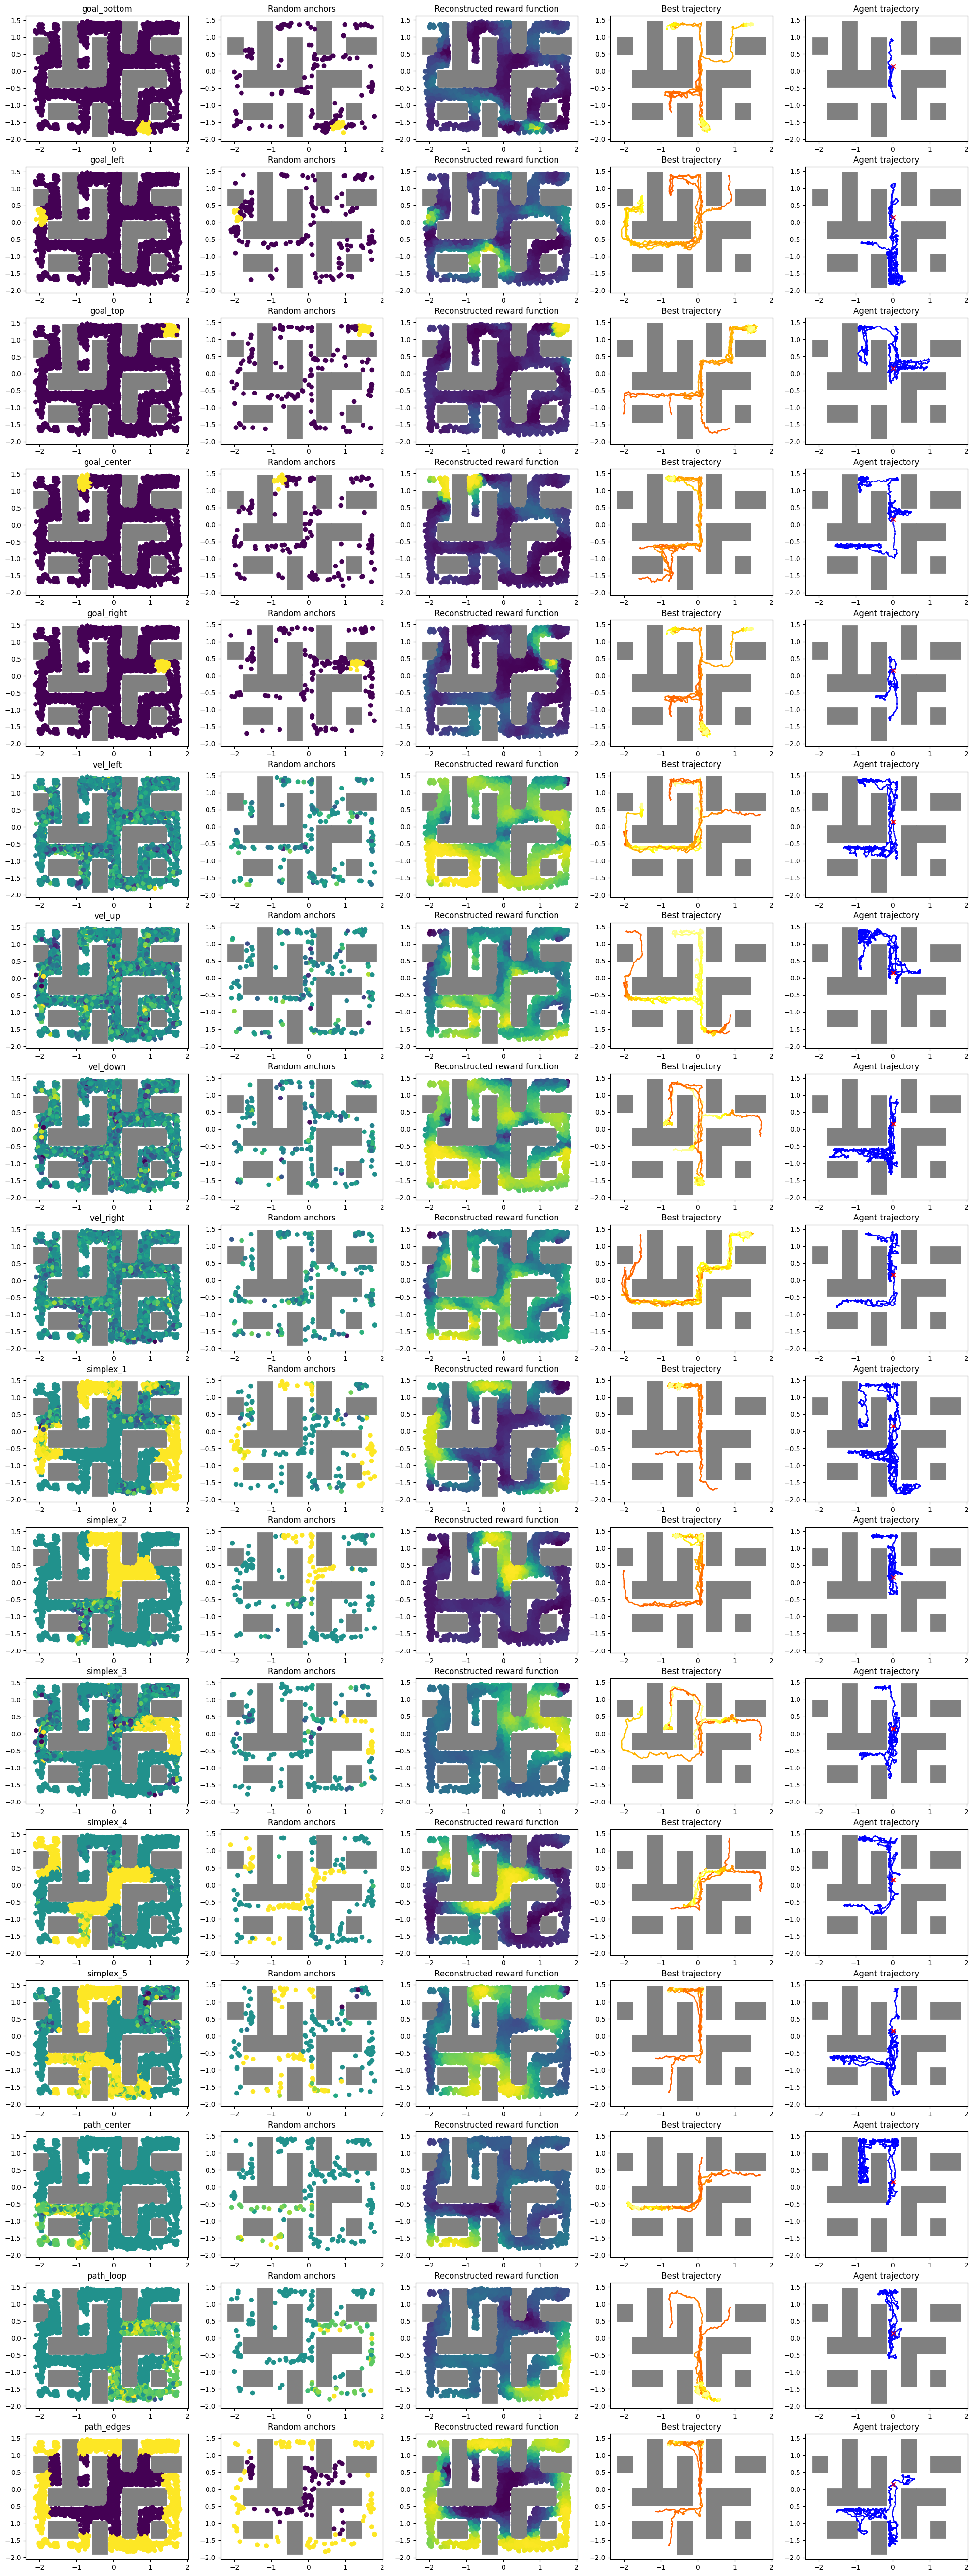

In [481]:
num_eval_anchors = 200

fig, all_axs = plt.subplots(len(benchmarks), 5, figsize=(5*5, len(benchmarks)*4))

reconstruction_losses = []

for benchmark_id in range(len(benchmarks)):
# for benchmark_id in range(4):
    
    axs = all_axs[benchmark_id]

    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]

    print(benchmark_test_label)

    reward_z_list, start_states_list, produced_trajectories_list, best_trajectories_idx_list, info = run_test(
        benchmark_id, num_evals=3, num_eval_anchors=num_eval_anchors
    )
    
    states = dataset_trajectories[0:300, :1000:10].reshape(-1, obs_dim)
    states = states.to(device)
        
    zi = reward_z_list[0].unsqueeze(0).repeat(states.shape[0], 1)
    with torch.no_grad():
        states_rewards = reward_generator.get_reward(states[..., FEATURES_TO_CONSIDER], zi).cpu()
    
    eval_states, eval_states_rewards = states.cpu(), states_rewards.cpu().flatten()

    

    axs[0].set_title(f'{benchmark_test_label}')
    axs[1].set_title('Random anchors')
    axs[2].set_title('Reconstructed reward function')
    axs[3].set_title('Best trajectory')
    axs[4].set_title('Agent trajectory')
    
    add_largest_maze_walls(axs[0])
    add_largest_maze_walls(axs[1])
    add_largest_maze_walls(axs[3])
    add_largest_maze_walls(axs[3])
    add_largest_maze_walls(axs[2])
    add_largest_maze_walls(axs[4])

    # x = dataset_trajectories[get_best_trajectory_info['best_traj_idx'][0][0]]
    # x = dataset_trajectories[best_trajectories_idx_list[i]]
    # axs[i].scatter(x[:, 0], x[:, 1], c='orange', s=1, alpha=np.linspace(0.5, 1, 1001))

    for j in range(5):
        x = dataset_trajectories[best_trajectories_idx_list[0][j]]
        axs[3].scatter(x[:, 0], x[:, 1], s=1, c=np.linspace(0.0, 0.8, 1001), cmap='hot', vmin=-1, vmax=1)
        


    anchors, anchors_rewards = info['anchors'], info['anchors_rewards']
    axs[1].scatter(anchors[..., 0].cpu(), anchors[..., 1].cpu(), c=anchors_rewards.cpu()[0], vmin=-1, vmax=1)    

    rews = benchmark_reward_function(denormalize_dataset_coords(dataset_trajectories[:, ::50]), benchmark_param)
    axs[0].scatter(dataset_trajectories[:, ::50, 0], dataset_trajectories[:, ::50, 1], c=rews, vmin=-1, vmax=1)

    # Reconstruction loss:
    true_rewards = benchmark_reward_function(denormalize_dataset_coords(eval_states), benchmark_param)
    reconstruction_loss = (eval_states_rewards - true_rewards).abs().mean().item()
    print(f'reconstruction_loss: {reconstruction_loss}')
    
    reconstruction_losses.append(reconstruction_loss)
    
    
    
    ################################################################################################################################
    
    anchors = info['anchors'].to(device)
    anchors_rewards = benchmark_reward_function(denormalize_dataset_coords(anchors.cpu()), benchmark_param).to(device)
    pad_mask = info['pad_mask'].to(device)

    mask = reward_generator.generate_boolean_mask(1, len(FEATURES_TO_CONSIDER), p=0.0)
    if KEEP_ONLY_COORDS:
        mask = torch.zeros_like(mask)
        mask[..., [0, 1]] = 1.
    mask = mask.to(device)
    anchors = anchors * mask.unsqueeze(1).repeat(1, num_eval_anchors, 1)

    eval_z, _ = reward_generator.get_z_from_anchors(anchors, anchors_rewards, pad_mask)

    with torch.no_grad():
        states_rewards = reward_generator.get_reward(
            eval_states[..., FEATURES_TO_CONSIDER].to(device) * mask.repeat(eval_states.shape[0], 1), 
            # eval_states[..., FEATURES_TO_CONSIDER].to(device), 
            eval_z.repeat(30000, 1)
        ).cpu()
        
    axs[2].scatter(eval_states[:, 0], eval_states[:, 1], c=states_rewards)
    
    ################################################################################################################################
    
    axs[4].scatter(produced_trajectories_list[:, :, 0], produced_trajectories_list[:, :, 1], c='blue', s=1, label='Agent trajectory')
    axs[4].scatter(start_states_list[0, 0], start_states_list[0, 1], c='red', marker='x')
    
    

    # break
    
print(f'mean reconstruction losses: {np.mean(reconstruction_losses)}')
print(f'std reconstruction losses: {np.std(reconstruction_losses)}')

In [ ]:
num_eval_anchors = 200

fig, all_axs = plt.subplots(len(benchmarks), 6, figsize=(6*5, len(benchmarks)*4))

reconstruction_losses = []

for benchmark_id in range(len(benchmarks)):
# for benchmark_id in range():
    
    axs = all_axs[benchmark_id]
    # benchmark_id = 11

    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
    
    print(benchmark_test_label)

    reward_z_list, start_states_list, produced_trajectories_list, best_trajectories_idx_list, best_trajectories_bench_idx_list, best_trajectories_from_alignement, info = run_test(
        benchmark_id, num_evals=3, num_eval_anchors=num_eval_anchors
    )
    
    break



    
    states = dataset_trajectories[0:300, :1000:10].reshape(-1, obs_dim)
    states = states.to(device)
        
    zi = reward_z_list[0].unsqueeze(0).repeat(states.shape[0], 1)
    with torch.no_grad():
        states_rewards = reward_generator_2.get_reward(states[..., FEATURES_TO_CONSIDER], zi).cpu()
    
    eval_states, eval_states_rewards = states.cpu(), states_rewards.cpu().flatten()

    

    axs[0].set_title(f'{benchmark_test_label}')
    axs[1].set_title('Random anchors')
    axs[2].set_title('Reconstructed reward function')
    axs[3].set_title('Alignement trajectory')
    axs[4].set_title('Best trajectory')
    axs[5].set_title('Agent trajectory')
    
    add_largest_maze_walls(axs[0])
    add_largest_maze_walls(axs[1])
    add_largest_maze_walls(axs[3])
    add_largest_maze_walls(axs[4])
    add_largest_maze_walls(axs[2])
    add_largest_maze_walls(axs[5])

    # x = dataset_trajectories[get_best_trajectory_info['best_traj_idx'][0][0]]
    # x = dataset_trajectories[best_trajectories_idx_list[i]]
    # axs[i].scatter(x[:, 0], x[:, 1], c='orange', s=1, alpha=np.linspace(0.5, 1, 1001))

    for j in range(5):
        x = dataset_trajectories[best_trajectories_bench_idx_list[0][j]]
        axs[4].scatter(x[:, 0], x[:, 1], s=1, c=np.linspace(0.0, 0.8, 1001), cmap='hot', vmin=-1, vmax=1)
        
    
    for j in range(5):
        x = dataset_trajectories[best_trajectories_from_alignement[j]]
        axs[3].scatter(x[:, 0], x[:, 1], s=1, c=np.linspace(0.0, 0.8, 1001), cmap='hot', vmin=-1, vmax=1)
 
        
        

    anchors, anchors_rewards = info['anchors'], info['anchors_rewards']
    axs[1].scatter(anchors[..., 0].cpu(), anchors[..., 1].cpu(), c=anchors_rewards.cpu()[0], vmin=-1, vmax=1)    

    rews = benchmark_reward_function(denormalize_dataset_coords(dataset_trajectories[:, ::50]), benchmark_param)
    axs[0].scatter(dataset_trajectories[:, ::50, 0], dataset_trajectories[:, ::50, 1], c=rews, vmin=-1, vmax=1)

    # Reconstruction loss:
    true_rewards = benchmark_reward_function(denormalize_dataset_coords(eval_states), benchmark_param)
    reconstruction_loss = (eval_states_rewards - true_rewards).abs().mean().item()
    print(f'reconstruction_loss: {reconstruction_loss}')
    
    reconstruction_losses.append(reconstruction_loss)
    
    
    
    ################################################################################################################################
    
    anchors = info['anchors'].to(device)
    anchors_rewards = benchmark_reward_function(denormalize_dataset_coords(anchors.cpu()), benchmark_param).to(device)
    pad_mask = info['pad_mask'].to(device)

    mask = reward_generator_2.generate_boolean_mask(1, len(FEATURES_TO_CONSIDER), p=0.0)
    if KEEP_ONLY_COORDS:
        mask = torch.zeros_like(mask)
        mask[..., [0, 1]] = 1.
    mask = mask.to(device)
    anchors = anchors * mask.unsqueeze(1).repeat(1, num_eval_anchors, 1)

    eval_z, _ = reward_generator_2.get_z_from_anchors(anchors, anchors_rewards, pad_mask)

    with torch.no_grad():
        states_rewards = reward_generator_2.get_reward(
            eval_states[..., FEATURES_TO_CONSIDER].to(device) * mask.repeat(eval_states.shape[0], 1), 
            # eval_states[..., FEATURES_TO_CONSIDER].to(device), 
            eval_z.repeat(30000, 1)
        ).cpu()
        
    axs[2].scatter(eval_states[:, 0], eval_states[:, 1], c=states_rewards)
    
    ################################################################################################################################
    
    axs[5].scatter(produced_trajectories_list[:, :, 0], produced_trajectories_list[:, :, 1], c='blue', s=1, label='Agent trajectory')
    axs[5].scatter(start_states_list[0, 0], start_states_list[0, 1], c='red', marker='x')
    
    

    # break
    
print(f'mean reconstruction losses: {np.mean(reconstruction_losses)}')
print(f'std reconstruction losses: {np.std(reconstruction_losses)}')

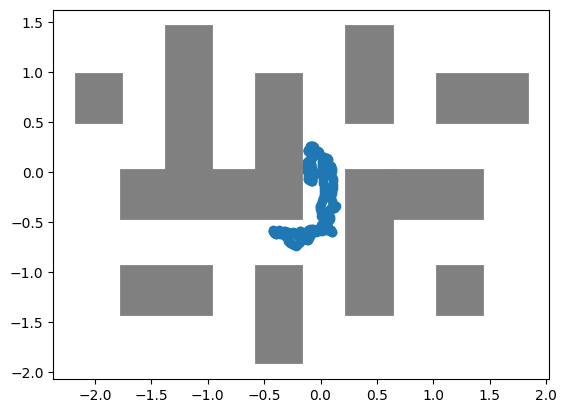

In [398]:
fig, ax = plt.subplots(1, 1)
ax.scatter(produced_trajectories_list[..., 0], produced_trajectories_list[..., 1])
add_largest_maze_walls(ax)